**Complete flow to remember**

In [ ]:
# CSV
#  ↓
# read_csv()
#  ↓
# X and y
#  ↓
# train_test_split()
#  ↓
# StandardScaler
#  ↓
# built_model(hp)
#  ↓
# Keras Tuner
#  ↓
# Search
#  ↓
# Best Hyperparameters
#  ↓
# Best Model
#  ↓
# Fit
#  ↓
# History
#  ↓
# Accuracy / Loss Graph
#  ↓
# Final Test Accuracy

1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import keras_tuner as kt

2. Read CSV file

In [2]:
df = pd.read_csv("diabetes.csv")

In [4]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


3. Separate X and y

In [6]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [7]:
print(X.shape)
print(y.shape)

(768, 8)
(768,)


4. Train-test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
print(X_train.shape)
print(X_test.shape)

(614, 8)
(154, 8)


5. Feature Scaling

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

6. Create the Hyperparameter Model

In [11]:
def built_model(hp):

    model = Sequential()

    # Number of hidden layers
    num_layers = hp.Int(
        'num_layers',
        min_value=1,
        max_value=7,
        step=1
    )

    # Create hidden layers
    for i in range(num_layers):

        # Number of neurons
        units = hp.Int(
            f'units{i+1}',
            min_value=8,
            max_value=128,
            step=8
        )

        # Activation function
        activation = hp.Choice(
            f'activation{i+1}',
            values=['relu', 'tanh', 'sigmoid']
        )

        # First hidden layer
        if i == 0:

            model.add(
                Dense(
                    units=units,
                    activation=activation,
                    input_dim=8
                )
            )

        # Other hidden layers
        else:

            model.add(
                Dense(
                    units=units,
                    activation=activation
                )
            )

    # Output layer
    model.add(
        Dense(
            1,
            activation='sigmoid'
        )
    )

    # Optimizer
    optimizer = hp.Choice(
        'optimizer',
        values=[
            'adam',
            'sgd',
            'rmsprop',
            'adadelta'
        ]
    )

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

7. Create Keras Tuner

In [12]:
tuner = kt.RandomSearch(
    built_model,
    objective='val_accuracy',
    max_trials=10,
    directory='my_dir',
    project_name='deep_learning_tuning',
    overwrite=True
)

e:\DL_by_CompusX\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8. See the model search space

In [13]:
tuner.search_space_summary()

Search space summary
Default search space size: 4
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 7, 'step': 1, 'sampling': 'linear'}
units1 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 128, 'step': 8, 'sampling': 'linear'}
activation1 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh', 'sigmoid'], 'ordered': False}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'sgd', 'rmsprop', 'adadelta'], 'ordered': False}


9. Start Hyperparameter Search

In [14]:
tuner.search(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Trial 10 Complete [00h 00m 02s]
val_accuracy: 0.7792207598686218

Best val_accuracy So Far: 0.7792207598686218
Total elapsed time: 00h 00m 20s


10. Results Summary

In [15]:
tuner.results_summary()

Results summary
Results in my_dir\deep_learning_tuning
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 09 summary
Hyperparameters:
num_layers: 5
units1: 48
activation1: relu
optimizer: rmsprop
units2: 32
activation2: tanh
units3: 120
activation3: relu
units4: 128
activation4: relu
units5: 96
activation5: tanh
units6: 112
activation6: relu
units7: 128
activation7: relu
Score: 0.7792207598686218

Trial 01 summary
Hyperparameters:
num_layers: 6
units1: 40
activation1: tanh
optimizer: adam
units2: 24
activation2: sigmoid
units3: 88
activation3: sigmoid
units4: 24
activation4: tanh
units5: 56
activation5: relu
units6: 8
activation6: relu
Score: 0.7662337422370911

Trial 04 summary
Hyperparameters:
num_layers: 2
units1: 104
activation1: sigmoid
optimizer: adam
units2: 128
activation2: tanh
units3: 16
activation3: sigmoid
units4: 128
activation4: sigmoid
units5: 128
activation5: tanh
units6: 120
activation6: relu
units7: 32
activation7: sigmoid
Score: 0.766233742

11. Get Best Hyperparameters

In [17]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

In [18]:
print(best_hp.values)

{'num_layers': 5, 'units1': 48, 'activation1': 'relu', 'optimizer': 'rmsprop', 'units2': 32, 'activation2': 'tanh', 'units3': 120, 'activation3': 'relu', 'units4': 128, 'activation4': 'relu', 'units5': 96, 'activation5': 'tanh', 'units6': 112, 'activation6': 'relu', 'units7': 128, 'activation7': 'relu'}


12. Print in a Clean Way

In [19]:
print("Best Number of Layers:", best_hp.get('num_layers'))
print("Best Optimizer:", best_hp.get('optimizer'))

for i in range(1, best_hp.get('num_layers') + 1):

    print(
        f"Layer {i}:",
        "Units =", best_hp.get(f'units{i}'),
        "| Activation =", best_hp.get(f'activation{i}')
    )

Best Number of Layers: 5
Best Optimizer: rmsprop
Layer 1: Units = 48 | Activation = relu
Layer 2: Units = 32 | Activation = tanh
Layer 3: Units = 120 | Activation = relu
Layer 4: Units = 128 | Activation = relu
Layer 5: Units = 96 | Activation = tanh


13. Get the Best Model

In [20]:
best_model = tuner.get_best_models(num_models=1)[0]

e:\DL_by_CompusX\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(store)


14. Train the Best Model

In [21]:
history = best_model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test)
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7801 - loss: 0.4380 - val_accuracy: 0.7662 - val_loss: 0.5746
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7980 - loss: 0.4155 - val_accuracy: 0.7403 - val_loss: 0.5755
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8127 - loss: 0.4083 - val_accuracy: 0.6688 - val_loss: 0.6091
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8046 - loss: 0.4010 - val_accuracy: 0.7143 - val_loss: 0.5970
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8160 - loss: 0.3961 - val_accuracy: 0.7013 - val_loss: 0.5843
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8176 - loss: 0.3866 - val_accuracy: 0.7532 - val_loss: 0.5693
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8176 - loss: 0.3805 - val_accuracy: 0.7532 - val_loss: 0.5902
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8225 - loss: 0.3693 - val_accuracy: 0.7208 - val_loss

15. Plot Accuracy

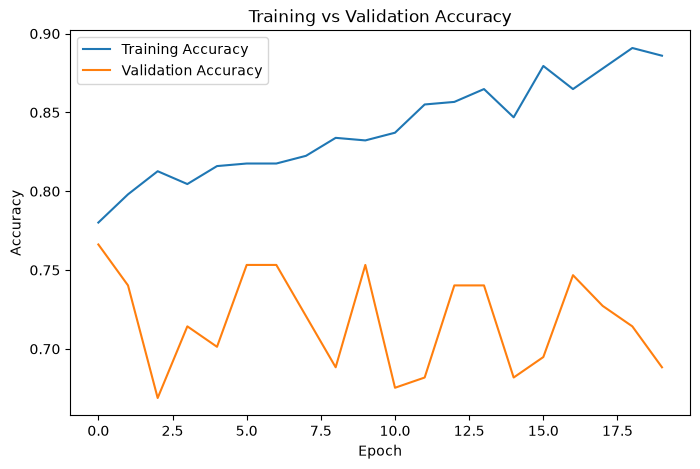

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()
plt.show()

16. Plot Loss

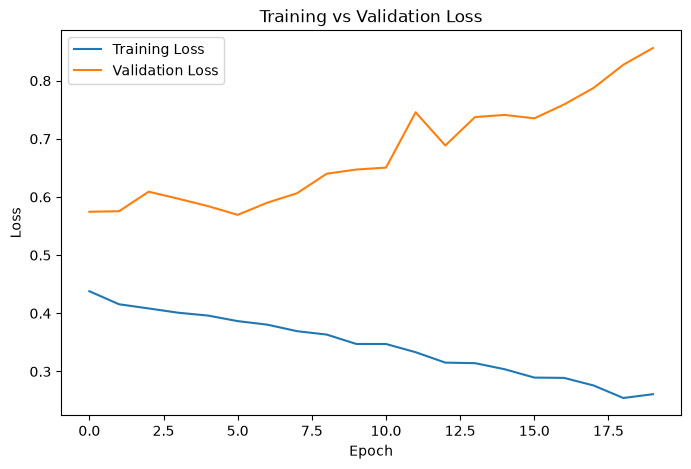

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()

17. Final Test Accuracy

In [24]:
loss, accuracy = best_model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6883 - loss: 0.8562 
Test Loss: 0.8562018871307373
Test Accuracy: 0.6883116960525513
